In [123]:
import yfinance as yf
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np

tickers = ["NVDA", "MSFT", "JNJ"]
data = yf.download(tickers=tickers, start="2025-03-17", end="2025-08-09")
close_prices = data["Close"] #Last 100 days adjusted close data
daily_returns = close_prices.pct_change().dropna()
daily_returns.to_csv("daily_returns.csv")
daily_returns.head()

C:\Users\I745460\AppData\Local\Temp\ipykernel_3996\800705690.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers, start="2025-03-17", end="2025-08-09")
[*********************100%***********************]  3 of 3 completed


Ticker,JNJ,MSFT,NVDA
Date,,,
2025-03-18,0.008659,-0.013327,-0.034301
2025-03-19,-0.007671,0.011212,0.018106
2025-03-20,0.000184,-0.002527,0.008594
2025-03-21,0.003742,0.011426,-0.007002
2025-03-24,-0.002078,0.004652,0.031521


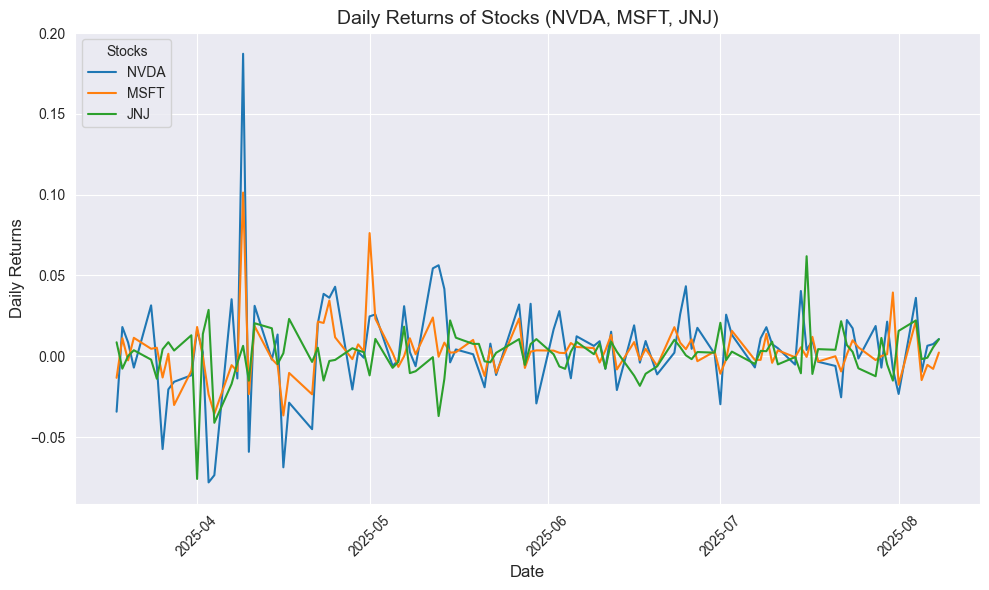

In [119]:
# Plot daily returns for each stock
plt.figure(figsize=(10, 6))

for ticker in tickers:
    plt.plot(daily_returns.index, daily_returns[ticker], label=ticker)

plt.title("Daily Returns of Stocks (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Returns", fontsize=12)
plt.legend(title="Stocks", loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

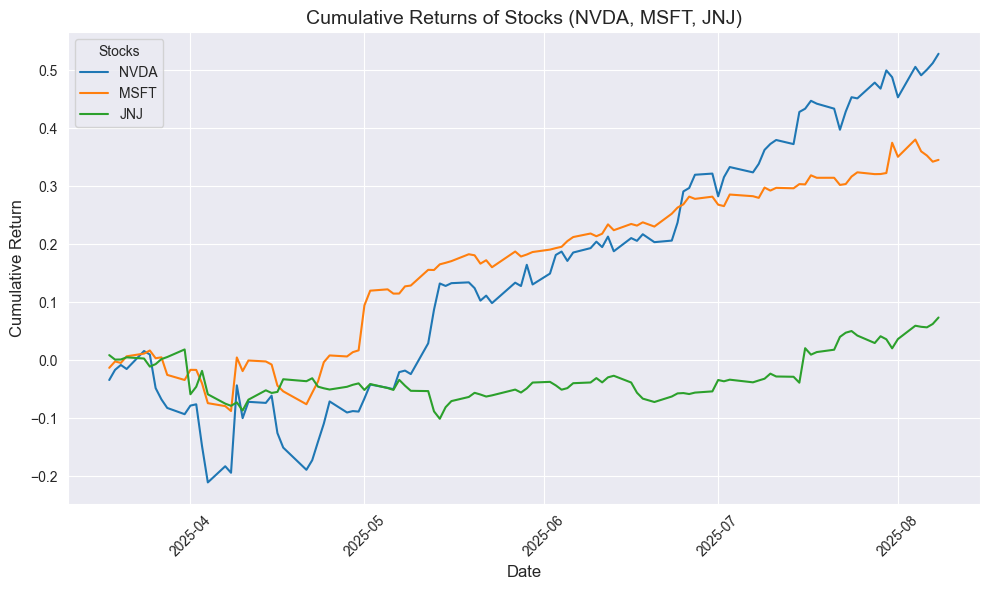

In [121]:
# Calculate cumulative returns for each stock
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Plot cumulative returns for each stock
plt.figure(figsize=(10, 6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Cumulative Returns of Stocks (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend(title="Stocks", loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

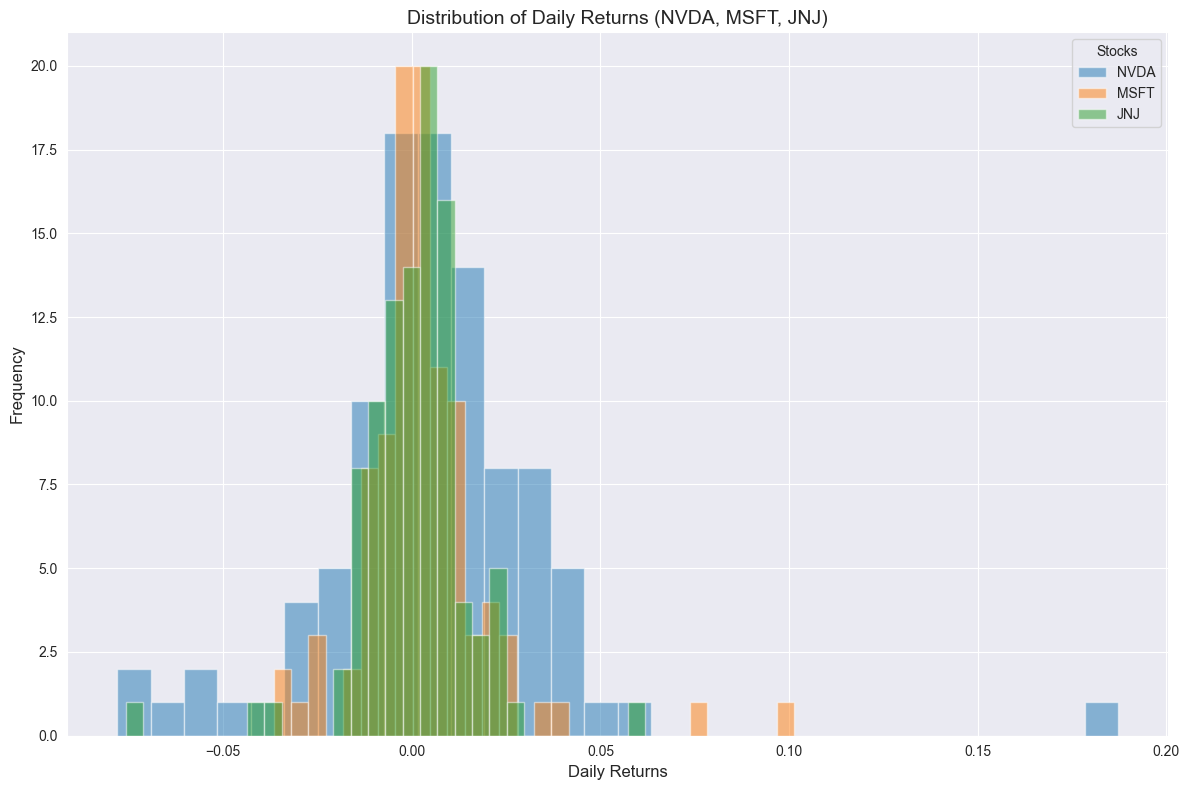

In [122]:
# Plot the distribution of daily returns for each stock
plt.figure(figsize=(12, 8))

for ticker in tickers:
    plt.hist(daily_returns[ticker], bins=30, alpha=0.5, label=ticker)

plt.title("Distribution of Daily Returns (NVDA, MSFT, JNJ)", fontsize=14)
plt.xlabel("Daily Returns", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Stocks")
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [118]:
data = pd.read_csv("daily_returns.csv", index_col='Date', parse_dates=True)

mu = data.mean().values
w = cp.Variable(3)

gamma = 0.015
epsilon = 0.05

abs_deviation = cp.abs(cp.multiply(w, data.values - mu))
MAD = cp.sum(cp.sum(abs_deviation, axis=1)) / data.shape[0]

objective = cp.Maximize(cp.sum(cp.multiply(w, mu)) - epsilon * MAD)
constraints = [cp.sum(w) == 1, w >= 0, MAD <= gamma]

problem = cp.Problem(objective, constraints)
problem.solve()

optimal_weights = w.value
optimal_weights
print(f"excpected daily portfolio return: {(mu @ optimal_weights) * 100:.3f}%")
print(f"portfilio MAD: {MAD.value:.5f}")

excpected daily portfolio return: 0.380%
portfilio MAD: 0.01500


C:\Users\I745460\PycharmProjects\Financial_DS_focus_sessions\.venv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


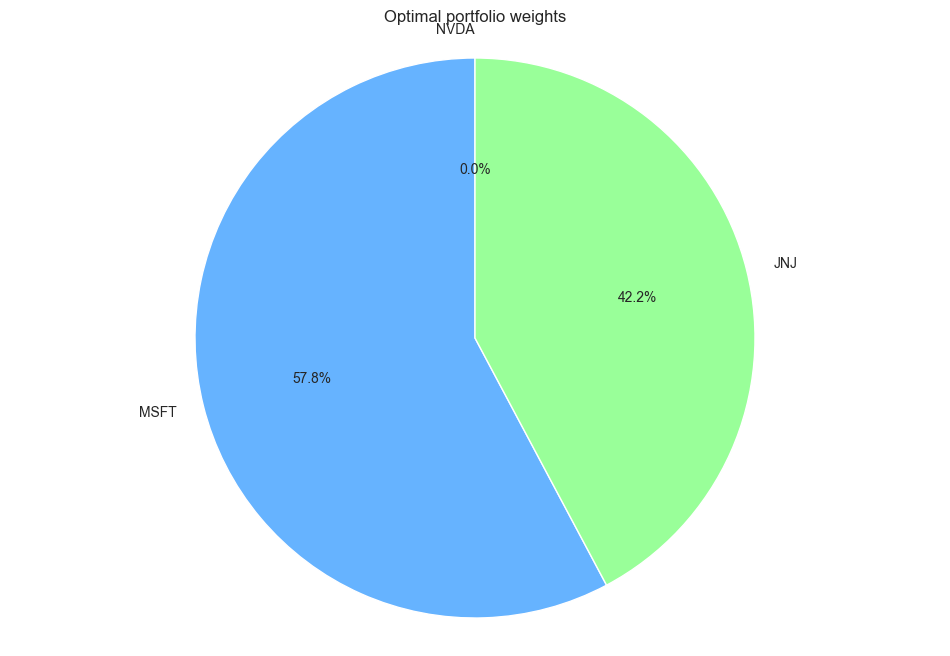

In [111]:
plt.figure(figsize=(12, 8))
plt.pie(optimal_weights, labels=tickers, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Optimal portfolio weights")
plt.axis('equal')
plt.show()

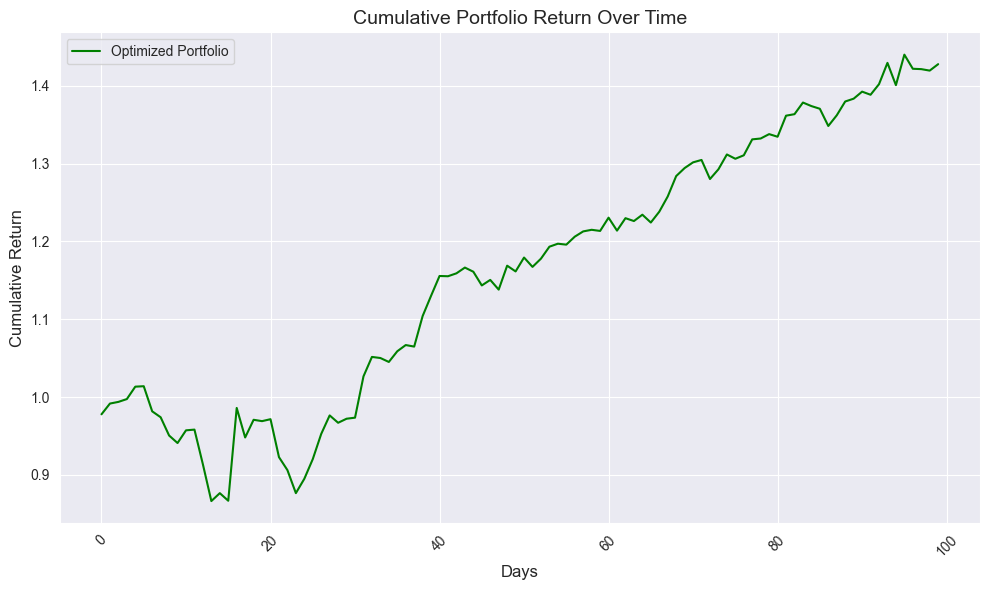

Optimal Portfolio Expected Daily Return: 0.380%
Optimal Portfolio Volatility (Risk): 2.214%


In [127]:
cov_matrix = daily_returns.cov().values
# 1. Expected return and volatility (risk) of the optimal portfolio
expected_return = np.sum(optimal_weights * mu)
portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# 2. Portfolio performance over time
portfolio_returns = np.dot(daily_returns.values, optimal_weights)
cumulative_portfolio_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(cumulative_portfolio_returns, label="Optimized Portfolio", color="green")
plt.title("Cumulative Portfolio Return Over Time", fontsize=14)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Output the results for the user
print(f"Optimal Portfolio Expected Daily Return: {expected_return * 100:.3f}%")
print(f"Optimal Portfolio Volatility (Risk): {portfolio_volatility * 100:.3f}%")